# 04 · EOC: proximity, capacity, and a briefing

**Mission:** identify facilities near a hypothetical incident and quantify available exercise capacity. Allow 35 minutes. Prerequisite: Lab 03.

**Run:** choose the Python (Pyodide) kernel in JupyterLite, then Run → Run All Cells. First use downloads Matplotlib. All training data are **SYNTHETIC** unless explicitly labeled LIVE. Downloads appear below and in `exports/`; the browser filesystem is separate from your computer. Each lab runs independently.

In [1]:
import sys
if sys.platform == "emscripten":
    import micropip
    await micropip.install("matplotlib")
import json, math
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from worldview_lab import (load, export, map_layer, chart_style, haversine_km,
    wilson_interval, shortest_times, freshness, normalize_quakes,
    validate_geojson, brief_request, validate_brief)
chart_style()

## Scenario: a hypothetical service interruption

A fictional incident at `(-77.10, 38.83)` triggers a **20 km screening radius**. This radius is an exercise parameter, not a forecast damage footprint. Distance alone cannot establish impact, safety, travel time, or a recommended dispatch.

In [2]:
INCIDENT=(-77.10,38.83);RADIUS_KM=20
facilities=load('facilities.geojson');screen=[]
for f in facilities['features']:
    p=f['properties'];lon,lat=f['geometry']['coordinates']
    d=haversine_km(*INCIDENT,lon,lat)
    screen.append({'id':p['id'],'name':p['name'],'distance_km':round(d,2),'open':p['open'],
                   'capacity':p['capacity'],'inside':d<=RADIUS_KM})
display(screen)
eligible=[r for r in screen if r['inside'] and r['open']]
print('Open capacity inside screening radius:',sum(r['capacity'] for r in eligible),'exercise slots')

[{'id': 'F01',
  'name': 'Harbor exercise clinic',
  'distance_km': 17.47,
  'open': True,
  'capacity': 70,
  'inside': True},
 {'id': 'F02',
  'name': 'Central exercise hospital',
  'distance_km': 0.0,
  'open': True,
  'capacity': 110,
  'inside': True},
 {'id': 'F03',
  'name': 'Ridge exercise clinic',
  'distance_km': 26.16,
  'open': True,
  'capacity': 55,
  'inside': False},
 {'id': 'F04',
  'name': 'South exercise shelter',
  'distance_km': 21.2,
  'open': False,
  'capacity': 90,
  'inside': False}]

Open capacity inside screening radius: 180 exercise slots


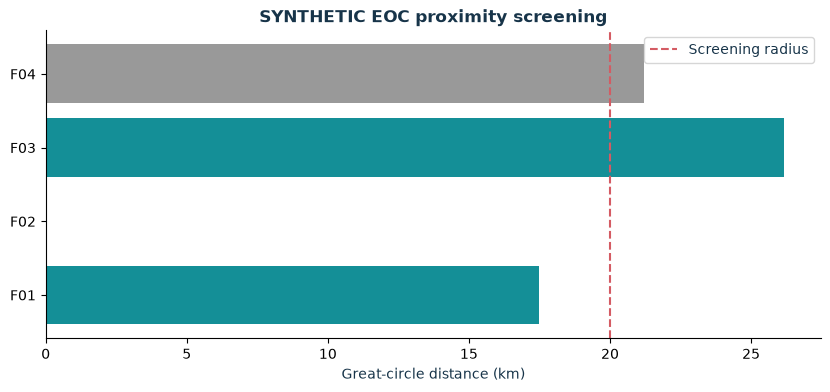

<iframe title="SYNTHETIC response facilities" referrerpolicy="strict-origin-when-cross-origin" style="width:100%;height:520px;border:0" srcdoc="<!doctype html><html lang="en"><meta charset="utf-8">
 <meta name="referrer" content="strict-origin-when-cross-origin">
 <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css">
 <style>body{margin:0;font:14px system-ui}#map{height:390px;background:#eef3f5}header{padding:10px;background:#102536;color:#fff}.controls{padding:8px;background:#f2f6f8}#map-status{display:block;margin-top:4px}</style>
 <header>SYNTHETIC response facilities | Select a feature to inspect its attributes and units</header>
 <div class="controls"><label><input id="basemap" type="checkbox"> OpenStreetMap background</label>
 <span id="map-status" role="status" aria-live="polite">Data layer ready. Background map off.</span></div>
 <div id="map" aria-label="Interactive geospatial data layer"></div>
 <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script><script>
 const data={"type": "FeatureCollection", "features": [{"type": "Feature", "id": "F01", "geometry": {"type": "Point", "coordinates": [-77.23, 38.71]}, "properties": {"id": "F01", "name": "Harbor exercise clinic", "capacity": 70, "open": true, "status": "SIMULATED", "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T11:30:00Z"}}, {"type": "Feature", "id": "F02", "geometry": {"type": "Point", "coordinates": [-77.1, 38.83]}, "properties": {"id": "F02", "name": "Central exercise hospital", "capacity": 110, "open": true, "status": "SIMULATED", "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T11:30:00Z"}}, {"type": "Feature", "id": "F03", "geometry": {"type": "Point", "coordinates": [-76.84, 38.95]}, "properties": {"id": "F03", "name": "Ridge exercise clinic", "capacity": 55, "open": true, "status": "SIMULATED", "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T11:30:00Z"}}, {"type": "Feature", "id": "F04", "geometry": {"type": "Point", "coordinates": [-76.91, 38.71]}, "properties": {"id": "F04", "name": "South exercise shelter", "capacity": 90, "open": false, "status": "SIMULATED", "source": "SYNTHETIC exercise v1", "observed_at": "2026-09-14T11:30:00Z"}}]},field="capacity",m=L.map('map').setView([38.85,-77.04],10);
 const layer=L.geoJSON(data,{style:f=>({color:'#15364a',weight:2,fillOpacity:.65,fillColor:f.properties[field]>=400?'#ef806f':f.properties[field]>=200?'#f4bc65':'#54c9c1'}),pointToLayer:(f,ll)=>L.circleMarker(ll,{radius:8,color:'#157b85'})});
 layer.eachLayer(l=>{const pre=document.createElement('pre');pre.textContent=JSON.stringify(l.feature.properties,null,2);l.bindPopup(pre)});layer.addTo(m);if(data.features.length)m.fitBounds(layer.getBounds());
 const toggle=document.getElementById('basemap'),status=document.getElementById('map-status');
 const tiles=L.tileLayer('https://tile.openstreetmap.org/{z}/{x}/{y}.png',{
 maxZoom:18,attribution:'© <a href="https://www.openstreetmap.org/copyright">OpenStreetMap contributors</a>'});
 tiles.on('tileerror',()=>{
 if(!m.hasLayer(tiles))return;
 m.removeLayer(tiles);toggle.checked=false;
 status.textContent='Background map unavailable. Your data remain visible. Select OpenStreetMap background to retry.';
 });
 tiles.on('load',()=>{if(m.hasLayer(tiles))status.textContent='Data layer and OpenStreetMap background ready.'});
 toggle.addEventListener('change',()=>{
 if(toggle.checked){status.textContent='Loading OpenStreetMap background…';tiles.addTo(m)}
 else{m.removeLayer(tiles);status.textContent='Data layer ready. Background map off.'}
 });
 // file:// and opaque embedding contexts cannot identify a referring website.
 if(/^https?:/.test(document.baseURI)){
 toggle.checked=true;if(toggle.checked)toggle.dispatchEvent(new Event('change'));
 }else{
 toggle.disabled=true;
 status.textContent='Data layer ready. Open this notebook through JupyterLite or an HTTP notebook server to load the background map.';
 }
 </script></html>">

In [3]:
fig,ax=plt.subplots()
ax.barh([r['id'] for r in screen],[r['distance_km'] for r in screen],color=['#148f97' if r['open'] else '#999999' for r in screen])
ax.axvline(RADIUS_KM,color='#d45b63',linestyle='--',label='Screening radius')
ax.set(xlabel='Great-circle distance (km)',title='SYNTHETIC EOC proximity screening');ax.legend();plt.show()
map_layer(facilities,value='capacity',title='SYNTHETIC response facilities')

In [4]:
evidence={'classification':'SYNTHETIC EXERCISE','scenario_clock':'2026-09-14T12:00:00Z',
 'evidence':[{'id':'EOC-01','metric':'open_capacity_within_radius','value':sum(r['capacity'] for r in eligible),'unit':'exercise slots','radius_km':RADIUS_KM},
             {'id':'EOC-02','metric':'facility_screen','rows':screen}],
 'limitations':['Spherical distance, not a road route','Capacity and open status are fictional','No hazard model or facility safety assessment']}
export('eoc-evidence.json',evidence)

WindowsPath('exports/eoc-evidence.json')

## Sensitivity and review

Change the radius to 10 km and 30 km. Close the central facility. Identify whether the conclusion changes because of geography or status. **Checkpoint:** a closed facility contributes zero available capacity even if it is closest.

Draft a three-sentence handoff: what was calculated, what remains unknown, and who should verify status. Use the exported evidence with Lab 08 for an optional Astra draft. A map should inform the review, not silently become a dispatch authority.

## Sources and attribution

[WHO EOC framework](https://www.who.int/publications/i/item/framework-for-a-public-health-emergency-operations-centre). This proximity exercise is an original teaching scenario, not a WHO operational procedure.

World View inspiration: [Kevin (Khoa) To, MIT](https://github.com/kevtoe/worldview). Original lab code, figures, and synthetic fixtures: JupyterLite WorldView contributors, MIT. See the [book references](https://jltobias.github.io/JupyterLite-WorldView/book/references.html) and repository notices for dependency and service terms.